# Generate a Road Network Graph Using `osmnx`
In this coding challenge, we are going to work with road network data from [OpenStreetMap](https://www.openstreetmap.org/#map=4/38.01/-95.84) using the [osmnx](https://osmnx.readthedocs.io/en/stable/index.html) python package.

*You need to answer ALL question prompts in this notebook. Question prompts are all italicized.*



### 1. Install the `osmnx` Library

Before you begin, ensure that the `osmnx` library is installed. You can do this by running the following command:




```
!pip install osmnx
```



In [2]:
!pip install osmnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.0.1
    Uninstalling geopandas-1.0.1:
      Successfully uninstalled geopandas-1.0.1


### 2. Import the Required Libraries
Next, you will need to import the necessary libraries in your Python code, and check the version.

In [3]:
import osmnx as ox
ox.__version__

'1.9.4'

### 3. Generate the Graph for a Specific Location

Now, you will generate a road network graph from a specific address.

In this example, we will use the school address: "13051 Whittington Drive, Houston, TX" and generate a graph of roads within a 5,000-meter radius (5 km). We will use the `ox.graph.graph_from_address()` method. (See documentation: https://osmnx.readthedocs.io/en/stable/user-reference.html)

* `address`: This is the starting location around which the graph will be generated. You can replace this address with any other address.
* `dist`: This specifies the radius (in meters) around the address for which the network will be created. In this case, the radius is 5,000 meters (or 5 km).
* `network_type`: This specifies the type of network you want to extract. Options include:
  * "drive": For driving (car) routes.
  * "walk": For pedestrian routes.
  * "bike": For cycling routes.
  * "all": For all types of routes.

In [4]:
# Add code in the blanks
G = ox.graph_from_address(
  address = "13051 Whittington Drive, Houston, TX",
  dist = 5000,
  network_type = "drive"
)

/usr/local/lib/python3.10/dist-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


### 4. Visualize the graph
We will use the `ox.project_graph()` and `ox.plot_graph()` methods to visualize the graph.

*4.1 Modify the `node_size` parameter. How does it change the visualisation?*

It makes the nodes larger/smaller - node_size=1 --> smaller circles representing nodes, node_size=99 --> larger circles representing nodes

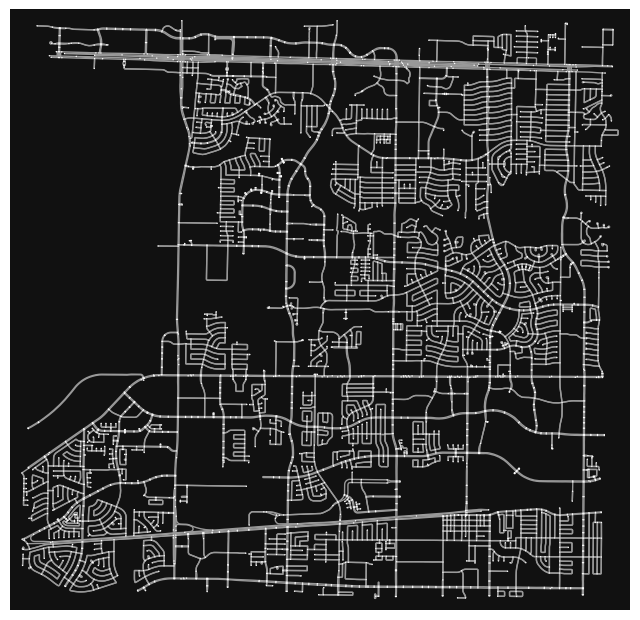

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
Gp = ox.project_graph(G)
ox.plot_graph(Gp, node_size=1)

### 5. Analyze the graph

*5.1 How many nodes are in the graph? [Use: `G.nodes()`]*

4600

In [6]:
nodes_list = list(G.nodes())
print(len(nodes_list))

4602


*5.2 How many edges are in the graph? [Use: `G.edges`]*

10257

In [7]:
edges_list = list(G.edges())
print(len(edges_list))

10263


*5.3 What information does the node store? Run the code below to get the information for the first node in the graph.*

The node stores the x and y value (longitude and latitude) of the location. *street count stuff?*

In [8]:
current_node = nodes_list[0]
print(f"Node {current_node}: {G.nodes[current_node]}")

Node 151365266: {'y': 29.749123, 'x': -95.5721842, 'street_count': 3}


*5.4 What information does the edge store? Is the edge weight part of this information?*


In [9]:
current_edge = edges_list[0]
print(f"Edge {current_edge}: {G.edges(current_edge)}")

Edge (151365266, 2114313821): [(151365266, 2114313821), (151365266, 2121580065), (2114313821, 151365266), (2114313821, 2114313964)]


*5.5 Create a new graph, `G_walk` by specifying `network_type` to "walk". Visualize it and compare it with the road network. How many nodes and edges does `G_walk` contain?*

20109; 57406

In [10]:
G_walk = ox.graph_from_address(
  address = "13051 Whittington Drive, Houston, TX",
  dist = 5000,
  network_type = "walk"
)

/usr/local/lib/python3.10/dist-packages/osmnx/graph.py:191: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  G = graph_from_bbox(


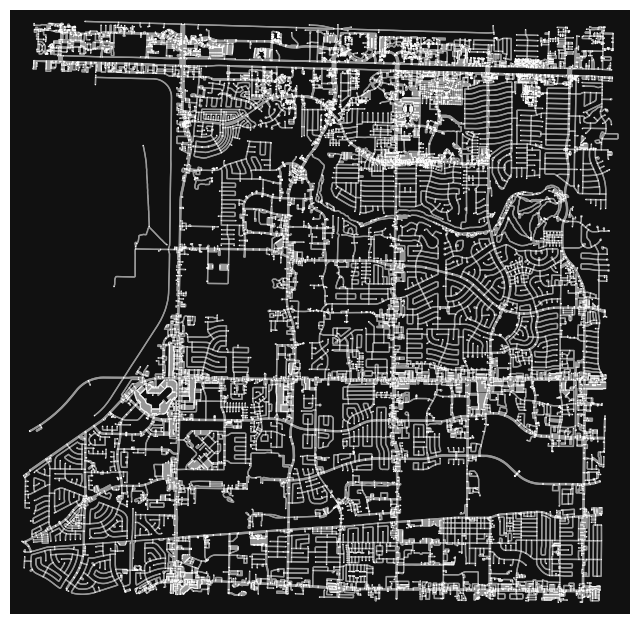

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
Gw = ox.project_graph(G_walk)
ox.plot_graph(Gw, node_size=1)

In [12]:
nodes_list = list(G_walk.nodes())
print(len(nodes_list))

20166


In [13]:
edges_list = list(G_walk.edges())
print(len(edges_list))

57564


# Shortest Path using `osmnx`

To find the shortest path, we will use the `shortest_path` method.

### 6. Setup Origin and Destination Nodes
But first, we need to specify the origin and destination using the latitude and longitude values for the location.



 Use google maps, to find the lat-long values of:
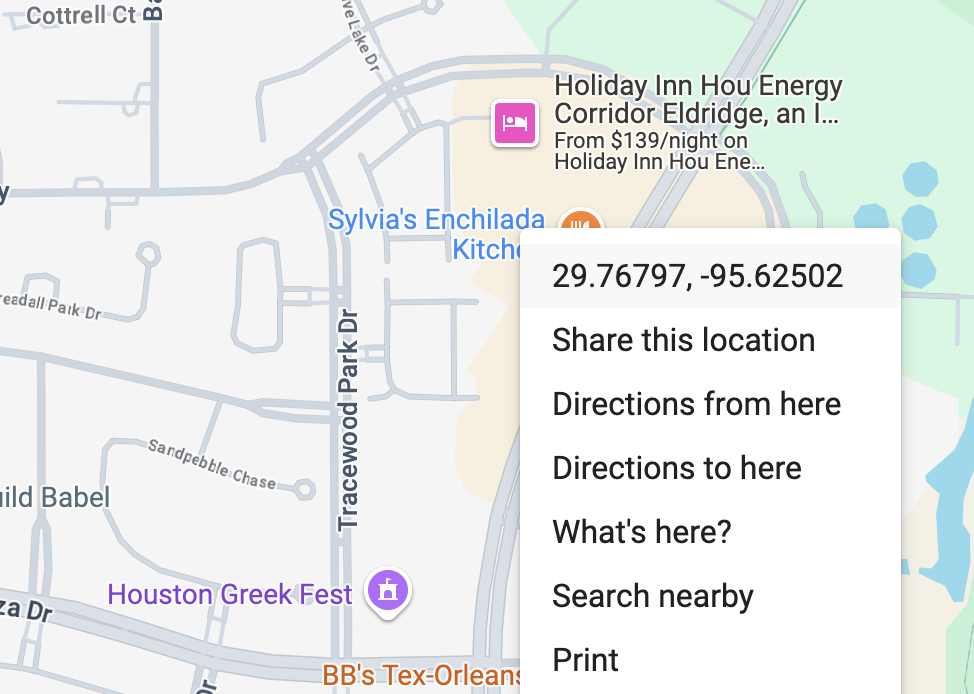
* origin - Village High School
* destination -  Sylvia's Enchilada Kitchen

*6.1 Specify the latitude & longitude as tuple.*

In [14]:
# origin = (__latitude__, __longitude__) # Point A
origin = (-95.61936461489813, 29.74620859706688)
# destination = (__latitude__, __longitude__) # Point B
destination = (-95.62502, 29.76797)

*6.2 Next use the `nearest_nodes()` method to get the node in the graph that is nearest to the specified location. Note that `x` is longitude and `y` is latitude.*

In [15]:
# origin_node = ox.distance.nearest_nodes(G, X=_________, Y=___________)
origin_node = ox.distance.nearest_nodes(G, X=-95.61936461489813, Y=29.74620859706688)
# destination_node = ox.distance.nearest_nodes(G, X=_________, Y=___________)
destination_node = ox.distance.nearest_nodes(G, X=-95.62502, Y=29.76797)

print({origin_node})
print({destination_node})



{152217532}
{2500920441}


### 7. Find shortest path using `osmnx` `shortest_path()` method
Now we are ready to find the shortest path between the origin and destination using the shortest_path method.

In [16]:
# route = ox.shortest_path(G, origin_node, destination_node)
route = ox.shortest_path(G, origin_node, destination_node)

print(f"shortest path from the Village School: {origin_node} to Sylvia's Enchilada Kitchen: {destination_node} is: {route}")

shortest path from the Village School: 152217532 to Sylvia's Enchilada Kitchen: 2500920441 is: [152217532, 4732918599, 4732918604, 152230013, 152230005, 152229982, 1211492516, 2121308489, 1211492955, 1211493041, 1211493149, 1211493042, 1211493205, 1211497513, 1211493796, 1211493711, 1211493838, 1211493859, 1211493930, 1211494060, 1211494213, 1211494164, 1211494596, 2057800632, 2057800674, 2500920441]


Visualise the shortest path using `plot_graph_route()` method.

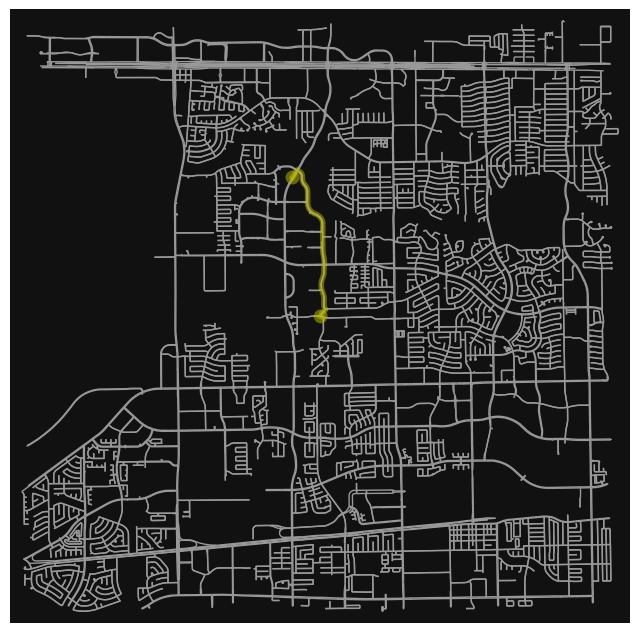

In [17]:
# fig, ax = ox.plot_graph_route(G, route, route_color="y", node_size=0)
fig, ax = ox.plot_graph_route(G, route, route_color="y", node_size=0)

# Shortest Path using your Dijkstra's method



*8.1 Use the `GraphL` class that you have already created in a previous lesson in this notebook. Note that `GraphL` class should have dijkstra_shortest_path() as a method.*

In [18]:
import heapq, math

class GraphL:
    def __init__(self, num_nodes = None, directed = False):
      self.dictionary = {}
      self.num_nodes = len(self.dictionary)
      self.directed = directed
      self.latlong = {}

    def add_edge(self, u, v, weight):
      if u not in self.dictionary:
        self.dictionary[u] = []
      if v not in self.dictionary:
        self.dictionary[v] = []
      self.dictionary[u].append((v, weight))
      if not self.directed:
        self.dictionary[v].append((u, weight))

    def remove_edge(self, u, v):
      if u in self.dictionary:
        for edge in self.dictionary[u]:
          if edge[0] == v:
            self.dictionary[u].remove(edge)

    def display(self):
      for node in self.dictionary:
        print(self.dictionary)
        for neighbor, weight in self.dictionary[node]:
          print({(node, neighbor, weight)})

    def get_neighbors(self, u):
      if u in self.dictionary:
        for x in self.dictionary[u]:
          print(x[0])

    def has_edge(self, u, v):
      if u in self.dictionary:
        for edge in self.dictionary[u]:
          if edge[0] == v:
            return True
      return False

    def add_node(self, u):
      if u not in self.dictionary:
        self.dictionary[u] = []
        self.num_nodes = self.num_nodes + 1

    def dijkstras_shortest_path(self, start, end):
      dist = {node: float('inf') for node in self.dictionary}
      dist[start] = 0
      priority_queue = [(0, start)]
      paths = {start: [start]}
      while priority_queue:
        path_distance, node = heapq.heappop(priority_queue)
        if node == end:
          return paths[node], dist[end]
        if node in self.dictionary:
          for neighbor, weight in self.dictionary[node]:
            new_distance = path_distance + weight
            if new_distance < dist[neighbor]:
              dist[neighbor] = new_distance
              heapq.heappush(priority_queue, (new_distance, neighbor))
              paths[neighbor] = paths[node] + [neighbor]
      return None, float('inf')

    def heuristic(self, lat1, lon1, lat2, lon2):
      r = 6371.0

      lat1 = math.radians(lat1)
      lon1 = math.radians(lon1)
      lat2 = math.radians(lat2)
      lon2 = math.radians(lon2)

      d_lat = lat2 - lat1
      d_lon = lon2 - lon1

      a = math.sin(d_lat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(d_lon / 2)**2
      c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

      distance = r * c
      return distance

    def a_star(self, start, goal):
      open_list = []
      heapq.heappush(open_list, (0, start))

      g_score = {node: float('inf') for node in self.dictionary}
      g_score[start] = 0

      came_from = {start: None}

      while open_list:
        current_node = heapq.heappop(open_list)[1]

        if current_node == goal:
          path = []
          while current_node:
              path.append(current_node)
              current_node = came_from[current_node]
          return path[::-1]

        for neighbor, cost in self.dictionary.get(current_node, []):
          tentative_g_score = g_score[current_node] + cost
          if tentative_g_score < g_score[neighbor]:
            came_from[neighbor] = current_node
            g_score[neighbor] = tentative_g_score

In [19]:
distance = GraphL.heuristic(GraphL, -95.61936461489813, 29.74620859706688, -95.62502, 29.76797) # still coordinates of Village School to Leslie's Kitchen - I expect a small number because they are so close
print(distance)

0.6720489427348392


*8.2 Now we will copy the nodes from the `osmnx` graph to our adjacency list graph representation.*

In [20]:
# myG = GraphL(directed=True)
myG = GraphL(10000000000, directed=True)

In [21]:
for node in G.nodes():
    latlong = (G.nodes[node]['x'], G.nodes[node]['y']) # add node using your add_node() method
    myG.add_node(tuple(latlong))
    for neighbor, data in G[node].items():
        for edge_data in data.values():
            weight = edge_data.get('length', 1)  # Assuming 'length' is the edge attribute
            myG.add_edge(node, neighbor, weight) # add edge using your add_edge() method

            break


*8.3 Display the graph using the display() method in the `GraphL` class.*

In [22]:
#myG.display()

* Get the shortest path by calling `dijkstra_shortest_path()` method with the newly created `myG` graph.

* Plot the path and compare it with the output of the `shortest_path()` from the `osmnx` package.

*8.4 Compare the results.Does your implementation give the same route as that of the `osmnx` package?*

In [23]:
print("dijkstras:")
dijkstra_path = myG.dijkstras_shortest_path( origin_node, destination_node)

dijkstras:


In [24]:
print("ox:")
osmnx_shortest_path = ox.shortest_path(G, origin_node, destination_node)
print(len(osmnx_shortest_path))

ox:
26


In [25]:
#, _ basically means we are ignoring the second value, which would be the distance,
# as we will be looking for shortest path anyway
dijkstra_path, _ = myG.dijkstras_shortest_path(origin_node, destination_node)
if dijkstra_path == osmnx_shortest_path:
    print("YAY")
else:
    print("NAY")



YAY


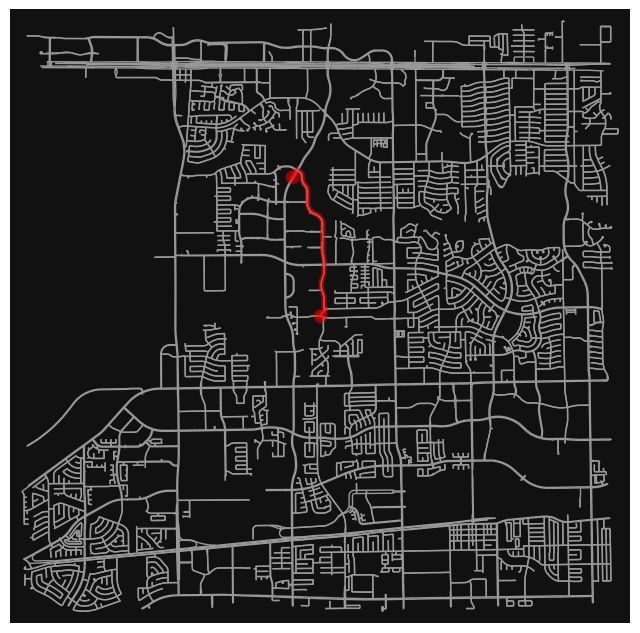

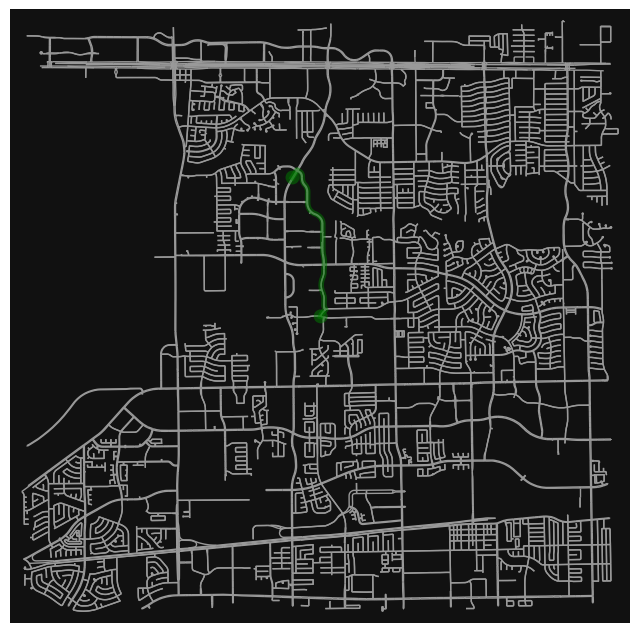

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [26]:
ox.plot_graph_route(G, osmnx_shortest_path, route_color="red", node_size=0)

ox.plot_graph_route(G, dijkstra_path, route_color="green", node_size=0)


# Your Turn
*9. Modify the graph to include a 20 km radius around an address of your choice. Choose at least 2 (origin, destination) pairs and compute shortest path using your Dijkstra's method. Visualize the results.*

In [27]:
for node in G.nodes():
  latlong = (G.nodes[node]['x'], G.nodes[node]['y'])
  g.add_node(node, tuple(latlong))
  for neighbor, data in G[node].items():
    for edge_data in data.values():
      weight = edge_data.get('length', 1)
      g.add_edge(node, neighbor, weight)

  break

NameError: name 'g' is not defined

#A*

In [ ]:
a_star_orginal_node = ox.distance.nearest_nodes(G, X=-95.61936461489813, Y=29.74620859706688)
a_star_destination_node = ox.distance.nearest_nodes(G, X=-95.62502, Y=29.76797)
myG.a_star_algorithm(a_star_orginal_node, a_star_destination_node)

In [ ]:
dijkstras_shortest_path = myG.dijkstras_shortest_path(origin_node, destination_node)

a_star_path = myGL.a_star(a_star_orginal_node, a_star_destination_node)

ox.plot_graph_route(G, dijkstras_shortest_path, route_color="orange", node_size=0)
ox.plot_graph_route(G, a_star_path, route_color="purple", node_size=0)